<a href="https://colab.research.google.com/github/Bilra-Hkr/DerielChaerahman_2411533007_ML2526/blob/main/Praktikum5/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 1. Import Library

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

import warnings; warnings.filterwarnings('ignore')

---
# 2. Load Dataset

In [111]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Dataset/train.csv')


print(f'Shape  : {df.shape}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape  : (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [112]:
# Info tipe data dan jumlah non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [113]:
# Distribusi label target
print('Distribusi label Survived:')
print(df['Survived'].value_counts())
print(f'\nPersentase selamat : {df["Survived"].mean()*100:.2f}%')
print(f'Persentase tidak   : {(1-df["Survived"].mean())*100:.2f}%')

Distribusi label Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Persentase selamat : 38.38%
Persentase tidak   : 61.62%


---
## 3. Eksplorasi Data (EDA)

In [114]:
# Cek missing values
print('=== Missing Values ===')
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Jumlah Missing': missing, 'Persen (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])

=== Missing Values ===
          Jumlah Missing  Persen (%)
Age                  177       19.87
Cabin                687       77.10
Embarked               2        0.22


# 4. Praproses Data

**Mengatasi anomali dataset:**
- `Age` : missing → hitung median
- `Cabin` : missing → drop kolom
- `Embarked` : 2 baris missing → hitung modus
- `Sex`, `Embarked` : kategorikal → encoding numerik
- `Name`, `Ticket`, `PassengerId` : tidak relevan → drop

In [115]:
def preprocess(dataframe):
    df_c = dataframe.copy()

    # 1. Ganti missing values
    df_c['Age'].fillna(df_c['Age'].median(), inplace=True)
    df_c['Embarked'].fillna(df_c['Embarked'].mode()[0], inplace=True)

    # 2. Drop kolom terlalu banyak missing
    df_c.drop(columns=['Cabin'], inplace=True)

    # 3. Encoding kategorik
    df_c['Sex']      = df_c['Sex'].map({'male': 1, 'female': 0})
    df_c['Embarked'] = df_c['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    # 4. Feature engineering sederhana
    df_c['FamilySize'] = df_c['SibSp'] + df_c['Parch'] + 1
    df_c['IsAlone']    = (df_c['FamilySize'] == 1).astype(int)

    # 5. Drop kolom tidak relevan
    df_c.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

    return df_c


df_processed = preprocess(df)

print(f'Shape setelah praproses : {df_processed.shape}')
print(f'Total missing values    : {df_processed.isnull().sum().sum()}')
df_processed.head()

Shape setelah praproses : (891, 10)
Total missing values    : 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,1,22.0,1,0,7.2500,0,2,0
1,1,1,0,38.0,1,0,71.2833,1,2,0
2,1,3,0,26.0,0,0,7.9250,0,1,1
3,1,1,0,35.0,1,0,53.1000,0,2,0
4,0,3,1,35.0,0,0,8.0500,0,1,1


In [116]:
# Bagi dataset : fitur (X) dan target (y)
X = df_processed.drop('Survived', axis=1)
y = df_processed['Survived']

print(X.columns)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'FamilySize', 'IsAlone'],
      dtype='object')


# 5. Implementasi K-Fold Cross Validation

In [117]:
K  = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)

results = {
    'fold': [], 'accuracy': [], 'precision': [],
    'recall': [], 'f1': [], 'roc_auc': []
}

print(f'=== K-Fold Cross Validation (K={K}) — Random Forest ===')
print('-' * 65)
print(f'{"Fold":>5} | {"Accuracy":>9} | {"Precision":>9} | {"Recall":>7} | {"F1":>7} | {"AUC":>7}')
print('-' * 65)

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)

    results['fold'].append(fold)
    results['accuracy'].append(acc)
    results['precision'].append(prec)
    results['recall'].append(rec)
    results['f1'].append(f1)
    results['roc_auc'].append(auc)

    print(f'{fold:>5} | {acc:>9.4f} | {prec:>9.4f} | {rec:>7.4f} | {f1:>7.4f} | {auc:>7.4f}')

print('-' * 65)
for m in ['accuracy','precision','recall','f1','roc_auc']:
    vals = results[m]
    print(f'  {m:<12} Mean={np.mean(vals):.4f}  Std={np.std(vals):.4f}')

=== K-Fold Cross Validation (K=5) — Random Forest ===
-----------------------------------------------------------------
 Fold |  Accuracy | Precision |  Recall |      F1 |     AUC
-----------------------------------------------------------------
    1 |    0.8156 |    0.7887 |  0.7568 |  0.7724 |  0.8992
    2 |    0.7978 |    0.7627 |  0.6716 |  0.7143 |  0.8505
    3 |    0.8146 |    0.7606 |  0.7714 |  0.7660 |  0.8768
    4 |    0.7978 |    0.7679 |  0.6515 |  0.7049 |  0.8107
    5 |    0.8315 |    0.7692 |  0.7692 |  0.7692 |  0.8590
-----------------------------------------------------------------
  accuracy     Mean=0.8114  Std=0.0127
  precision    Mean=0.7698  Std=0.0100
  recall       Mean=0.7241  Std=0.0517
  f1           Mean=0.7454  Std=0.0294
  roc_auc      Mean=0.8592  Std=0.0294


---
## 6. Visualisasi Hasil K-Fold

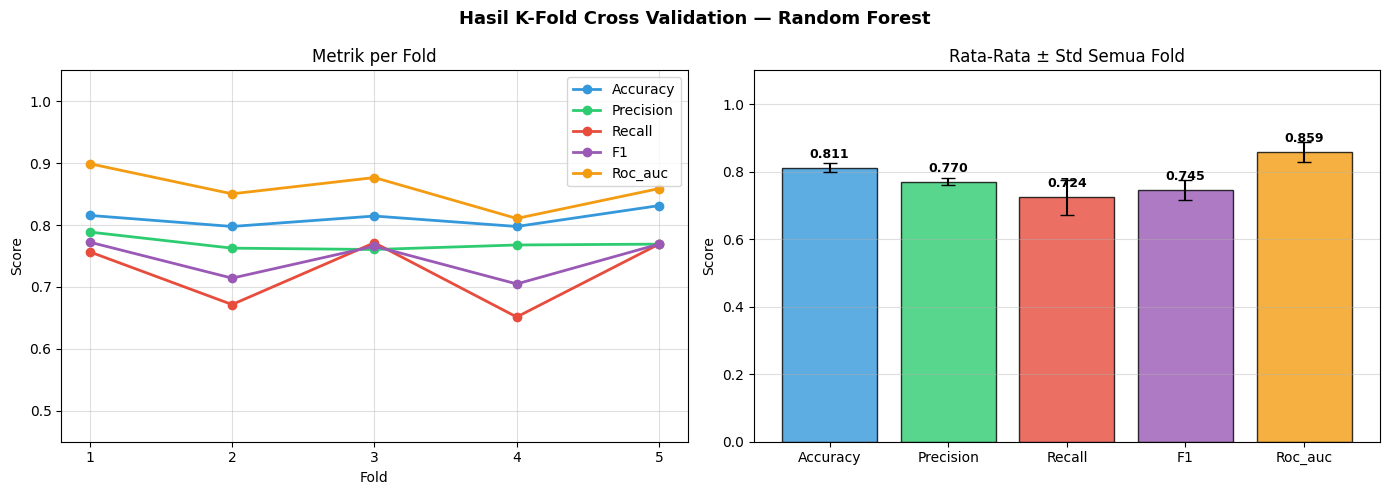

In [118]:
results_df = pd.DataFrame(results)
metrics    = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
colors     = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hasil K-Fold Cross Validation — Random Forest', fontsize=13, fontweight='bold')

# Line chart: metrik per fold
for metric, color in zip(metrics, colors):
    axes[0].plot(results_df['fold'], results_df[metric],
                 marker='o', label=metric.capitalize(), color=color, linewidth=2)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrik per Fold')
axes[0].set_xticks(range(1, K+1))
axes[0].set_ylim(0.45, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Bar chart: rata-rata ± std
means = [np.mean(results[m]) for m in metrics]
stds  = [np.std(results[m])  for m in metrics]
x_pos = np.arange(len(metrics))
bars  = axes[1].bar(x_pos, means, yerr=stds, capsize=5,
                    color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([m.capitalize() for m in metrics])
axes[1].set_ylabel('Score')
axes[1].set_title('Rata-Rata ± Std Semua Fold')
axes[1].set_ylim(0, 1.1)
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02, f'{mean:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

---
## 7. Confusion Matrix Fold Terbaik

Fold terbaik (F1 tertinggi) : Fold 1
F1-Score                    : 0.7724


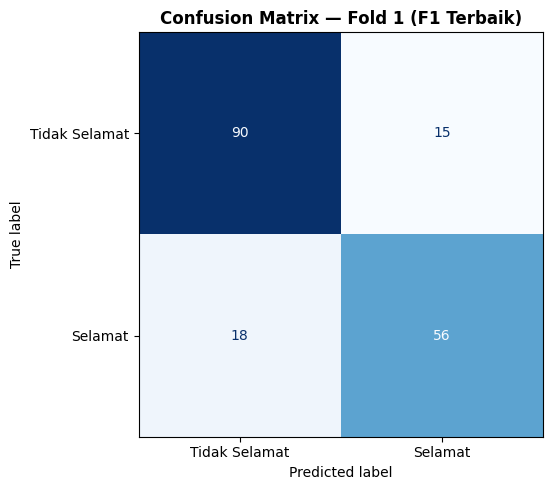


True Negative  (TN) : 90  — Tidak selamat, diprediksi tidak selamat (BENAR)
False Positive (FP) : 15  — Tidak selamat, diprediksi selamat (SALAH)
False Negative (FN) : 18  — Selamat, diprediksi tidak selamat (SALAH)
True Positive  (TP) : 56  — Selamat, diprediksi selamat (BENAR)


In [119]:
best_fold_idx = int(np.argmax(results['f1']))
best_fold_num = results['fold'][best_fold_idx]
print(f'Fold terbaik (F1 tertinggi) : Fold {best_fold_num}')
print(f'F1-Score                    : {results["f1"][best_fold_idx]:.4f}')

fold_list = list(kf.split(X))
tr_idx, te_idx = fold_list[best_fold_idx]

model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
y_pred_best = model.predict(X.iloc[te_idx])

cm = confusion_matrix(y.iloc[te_idx], y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Tidak Selamat', 'Selamat'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Fold {best_fold_num} (F1 Terbaik)', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nTrue Negative  (TN) : {tn}  — Tidak selamat, diprediksi tidak selamat (BENAR)')
print(f'False Positive (FP) : {fp}  — Tidak selamat, diprediksi selamat (SALAH)')
print(f'False Negative (FN) : {fn}  — Selamat, diprediksi tidak selamat (SALAH)')
print(f'True Positive  (TP) : {tp}  — Selamat, diprediksi selamat (BENAR)')

---
## 8. Feature Importance

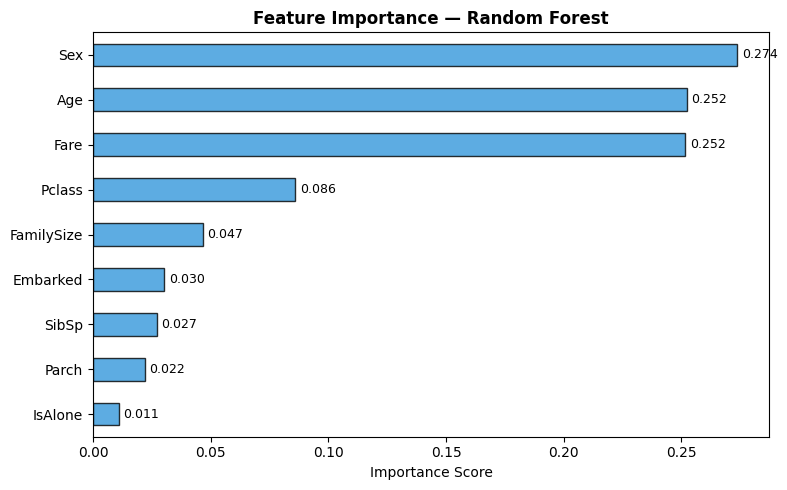

In [120]:
model_full = RandomForestClassifier(n_estimators=100, random_state=42)
model_full.fit(X, y)

importances = pd.Series(model_full.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black', alpha=0.8)
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
ax.set_xlabel('Importance Score')
for i, (val, name) in enumerate(zip(importances, importances.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. Perbandingan: Holdout vs K-Fold Manual vs cross_val_score

In [121]:
# Metode 1: Holdout (80/20)
X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X, y, test_size=0.2, random_state=42)
m_h = RandomForestClassifier(n_estimators=100, random_state=42)
m_h.fit(X_tr_h, y_tr_h)
y_pr_h = m_h.predict(X_te_h)

holdout_acc = accuracy_score(y_te_h, y_pr_h)
holdout_f1  = f1_score(y_te_h, y_pr_h)

# Metode 2: K-Fold Manual (section 5)
kfold_acc_mean = np.mean(results['accuracy'])
kfold_acc_std  = np.std(results['accuracy'])
kfold_f1_mean  = np.mean(results['f1'])
kfold_f1_std   = np.std(results['f1'])

# Metode 3: cross_val_score bawaan sklearn
cv_acc = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y, cv=5, scoring='f1')

# Tampilkan ringkasan
comparison = pd.DataFrame({
    'Metode': ['Holdout (80/20)', 'K-Fold Manual (k=5)', 'cross_val_score (k=5)'],
    'Accuracy': [f'{holdout_acc:.4f}',
                 f'{kfold_acc_mean:.4f} ± {kfold_acc_std:.4f}',
                 f'{cv_acc.mean():.4f} ± {cv_acc.std():.4f}'],
    'F1-Score': [f'{holdout_f1:.4f}',
                 f'{kfold_f1_mean:.4f} ± {kfold_f1_std:.4f}',
                 f'{cv_f1.mean():.4f} ± {cv_f1.std():.4f}']
})
print('=== Perbandingan Metode Validasi ===')
print(comparison.to_string(index=False))

=== Perbandingan Metode Validasi ===
               Metode        Accuracy        F1-Score
      Holdout (80/20)          0.8324          0.7945
  K-Fold Manual (k=5) 0.8114 ± 0.0127 0.7454 ± 0.0294
cross_val_score (k=5) 0.8115 ± 0.0315 0.7467 ± 0.0503


# 10. Percobaan K-Fold dengan K = 5, 7, dan 10

In [122]:
k_values  = [5, 7, 10]
metrics   = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
all_results = {}

for k in k_values:
    kf_exp = KFold(n_splits=k, shuffle=True, random_state=42)
    fold_data = {m: [] for m in metrics}

    print(f'\n=== K-Fold (K={k}) ===')
    print('-' * 65)
    print(f'{"Fold":>5} | {"Accuracy":>9} | {"Precision":>9} | {"Recall":>7} | {"F1":>7} | {"AUC":>7}')
    print('-' * 65)

    for fold, (tr_idx, te_idx) in enumerate(kf_exp.split(X), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        m = RandomForestClassifier(n_estimators=100, random_state=42)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:, 1]

        acc  = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, zero_division=0)
        rec  = recall_score(y_te, y_pred, zero_division=0)
        f1   = f1_score(y_te, y_pred, zero_division=0)
        auc  = roc_auc_score(y_te, y_prob)

        for key, val in zip(metrics, [acc, prec, rec, f1, auc]):
            fold_data[key].append(val)

        print(f'{fold:>5} | {acc:>9.4f} | {prec:>9.4f} | {rec:>7.4f} | {f1:>7.4f} | {auc:>7.4f}')

    print('-' * 65)
    for met in metrics:
        vals = fold_data[met]
        print(f'  {met:<12} → Mean={np.mean(vals):.4f}  Std={np.std(vals):.4f}')

    all_results[k] = fold_data


=== K-Fold (K=5) ===
-----------------------------------------------------------------
 Fold |  Accuracy | Precision |  Recall |      F1 |     AUC
-----------------------------------------------------------------
    1 |    0.8156 |    0.7887 |  0.7568 |  0.7724 |  0.8992
    2 |    0.7978 |    0.7627 |  0.6716 |  0.7143 |  0.8505
    3 |    0.8146 |    0.7606 |  0.7714 |  0.7660 |  0.8768
    4 |    0.7978 |    0.7679 |  0.6515 |  0.7049 |  0.8107
    5 |    0.8315 |    0.7692 |  0.7692 |  0.7692 |  0.8590
-----------------------------------------------------------------
  accuracy     → Mean=0.8114  Std=0.0127
  precision    → Mean=0.7698  Std=0.0100
  recall       → Mean=0.7241  Std=0.0517
  f1           → Mean=0.7454  Std=0.0294
  roc_auc      → Mean=0.8592  Std=0.0294

=== K-Fold (K=7) ===
-----------------------------------------------------------------
 Fold |  Accuracy | Precision |  Recall |      F1 |     AUC
-----------------------------------------------------------------
 

### Visualisasi Perbandingan nilai K (5,7,10)

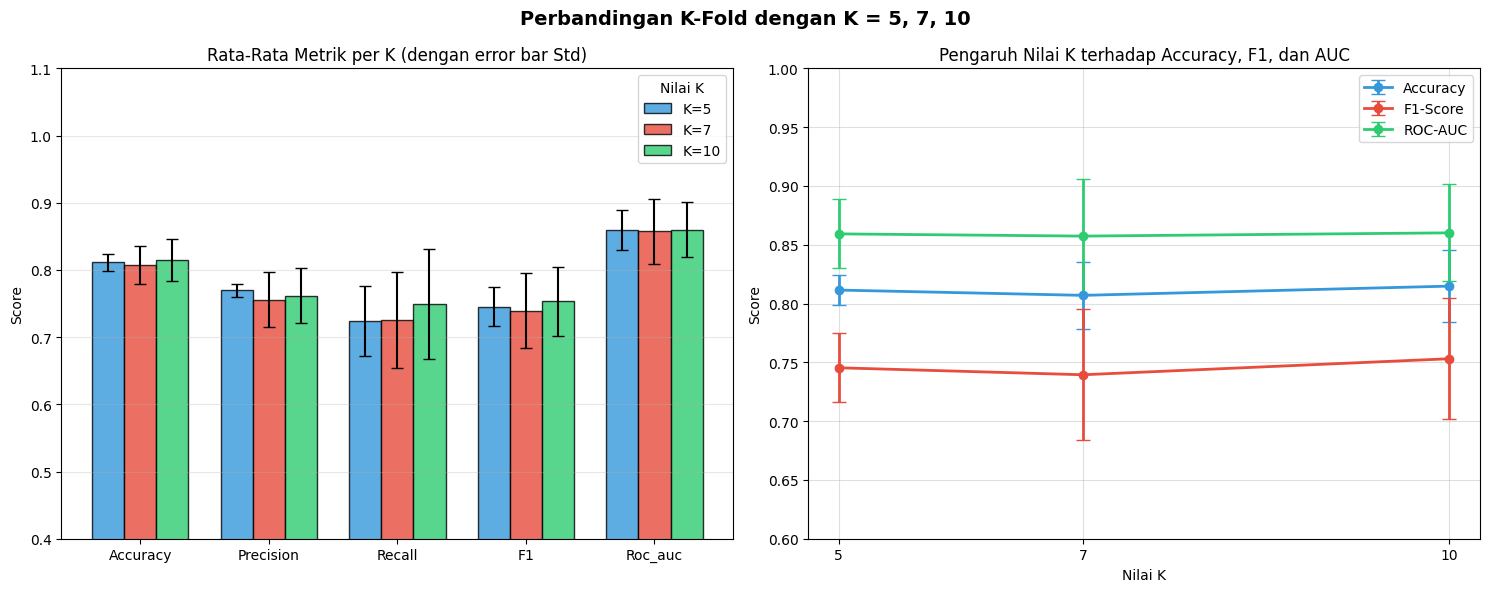

In [123]:
colors_k = {'5': '#3498db', '7': '#e74c3c', '10': '#2ecc71'}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Perbandingan K-Fold dengan K = 5, 7, 10', fontsize=14, fontweight='bold')

# --- Plot 1: Grouped bar chart rata-rata per metrik ---
x      = np.arange(len(metrics))
width  = 0.25
offset = [-width, 0, width]

for i, k in enumerate(k_values):
    means = [np.mean(all_results[k][m]) for m in metrics]
    stds  = [np.std(all_results[k][m])  for m in metrics]
    bars  = axes[0].bar(x + offset[i], means, width, yerr=stds,
                        label=f'K={k}', capsize=4,
                        color=list(colors_k.values())[i],
                        alpha=0.8, edgecolor='black')

axes[0].set_xticks(x)
axes[0].set_xticklabels([m.capitalize() for m in metrics])
axes[0].set_ylabel('Score')
axes[0].set_title('Rata-Rata Metrik per K (dengan error bar Std)')
axes[0].set_ylim(0.4, 1.1)
axes[0].legend(title='Nilai K')
axes[0].grid(True, alpha=0.3, axis='y')

# --- Plot 2: Line chart Accuracy mean & std per K ---
k_labels = [str(k) for k in k_values]
acc_means = [np.mean(all_results[k]['accuracy']) for k in k_values]
acc_stds  = [np.std(all_results[k]['accuracy'])  for k in k_values]
f1_means  = [np.mean(all_results[k]['f1'])        for k in k_values]
f1_stds   = [np.std(all_results[k]['f1'])         for k in k_values]
auc_means = [np.mean(all_results[k]['roc_auc'])   for k in k_values]
auc_stds  = [np.std(all_results[k]['roc_auc'])    for k in k_values]

for label, means, stds, color in [
    ('Accuracy', acc_means, acc_stds, '#3498db'),
    ('F1-Score', f1_means,  f1_stds,  '#e74c3c'),
    ('ROC-AUC',  auc_means, auc_stds, '#2ecc71')
]:
    axes[1].errorbar(k_values, means, yerr=stds,
                     label=label, marker='o', linewidth=2,
                     capsize=5, color=color)

axes[1].set_xlabel('Nilai K')
axes[1].set_ylabel('Score')
axes[1].set_title('Pengaruh Nilai K terhadap Accuracy, F1, dan AUC')
axes[1].set_xticks(k_values)
axes[1].set_ylim(0.6, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Visualisasi Distribusi Per-Fold (Boxplot)

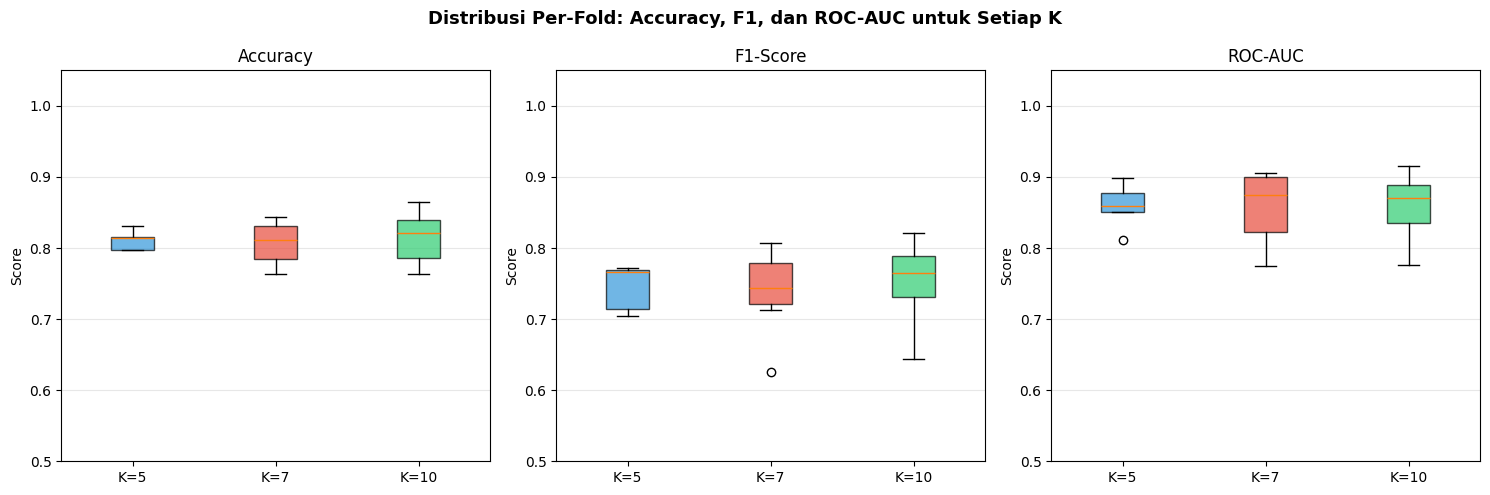

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Per-Fold: Accuracy, F1, dan ROC-AUC untuk Setiap K',
             fontsize=13, fontweight='bold')

plot_metrics = ['accuracy', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'F1-Score', 'ROC-AUC']

for ax, met, label in zip(axes, plot_metrics, metric_labels):
    data = [all_results[k][met] for k in k_values]
    bp = ax.boxplot(data, labels=[f'K={k}' for k in k_values],
                    patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c', '#2ecc71']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(label)
    ax.set_ylabel('Score')
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()